In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from sklearn.model_selection import train_test_split
import xgboost as xgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import uproot
import pickle
import nue_booster
import importlib
importlib.reload(nue_booster)
import awkward
from typing import List, Tuple, Any, Union
from numpy.typing import NDArray
import hashlib
import logging
import os
import yaml
from numu_tki import selection_1muNp 
from numu_tki import signal_1muNp 
from numu_tki import tki_calculators 

import localSettings as ls

import sys, os 
from data_loading import load_runs

from microfit.selections import get_selection_query

In [3]:
# Load in samples
# RUN = ["5_nuepresel"]
RUN = ["4a_nuepresel","4b_nuepresel","4c_nuepresel","4d_nuepresel","5_nuepresel"]
# RUN = ["4a", "4b", "4c", "4d", "5"]
# RUN = ["5_nuepresel"]
rundata, mc_weights, data_pot = load_runs(
    RUN,
    data="bnb",
    truth_filtered_sets=["nue", "drt", "nc_pi0"],
    # truth_filtered_sets=["nue", "drt"],
    loadpi0variables=True,
    loadshowervariables=True, # Loads in all variables we might want, including BDT variables (use_bdt=True asserts that these variables are loaded)
    loadrecoveryvars=True,
    loadsystematics=False,    # Set to false when we don't have event weights
    load_crt_vars=True,
    loadnumuvariables=True,
    use_bdt = False,          # Set use_BDT to false since we are training the BDT here, not using it
    load_lee=False,
    enable_cache=True,
    blinded=True,             # Set blinded to true, no training on data!!
)

Loading run 4a_nuepresel
Loading run 4b_nuepresel
Loading run 4c_nuepresel
Loading run 4d_nuepresel
Loading run 5_nuepresel


In [4]:
df_nu=rundata["mc"]
df_nue=rundata["nue"]
df_dirt=rundata["drt"]
df_ncpi0=rundata["nc_pi0"]
df_ext=rundata["ext"]

In [5]:
print(df_nue["is_signal"])
print(df_nue["category"])
# print(df_nu)

0          True
1         False
2         False
3         False
4          True
          ...  
102672    False
102673     True
102674    False
102675    False
102676    False
Name: is_signal, Length: 350757, dtype: bool
0         11
1          1
2         10
3         10
4         11
          ..
102672     1
102673    11
102674     1
102675     1
102676     5
Name: category, Length: 350757, dtype: int32


In [6]:
# Split dataframes into training and testing samples
train_nu, test_nu = train_test_split(df_nu, test_size=0.5, random_state=1990)
train_nue, test_nue = train_test_split(df_nue, test_size=0.5, random_state=1990)
train_dirt, test_dirt = train_test_split(df_dirt, test_size=0.5, random_state=1990)
train_ncpi0, test_ncpi0 = train_test_split(df_ncpi0, test_size=0.5, random_state=1990)
train_ext, test_ext = train_test_split(df_ext, test_size=0.5, random_state=1990)

# Try only splitting nc pi0 and nue into train and test samples, and everything else as just test
# Other way is as I have it now, split everything

In [7]:
# print(test_nu["run"])
# print(test_nue["run"])
# print(test_dirt["run"])
# print(test_ncpi0["run"])
# print(test_ext["run"])

In [8]:
# # Apply MC query and split into test and train samples
# MCQUERY = '((abs(nu_pdg)==12 & ccnc==0) | mcf_pass_ccpi0==1 | mcf_pass_ncpi0==1 | mcf_pass_ccnopi==1 | mcf_pass_ncnopi==1 | mcf_pass_cccpi==1 | mcf_pass_nccpi==1)'
# test_nu = df_nu.query('~'+MCQUERY)
# train_nu = df_nu.query(MCQUERY)

In [9]:
# test_nue.to_csv(os.path.join("/exp/uboone/data/users/kpletcher/slimmedFiles/slimmedMCC910/bdt", "run45_train_nue.csv"), index=False)

In [10]:
# Define set of samples, training and testing all included
samples = {
    "mc": (train_nu, test_nu),
    "nue": (train_nue, test_nue),
    "dirt": (train_dirt, test_dirt),
    "ncpi0": (train_ncpi0, test_ncpi0),
    "ext": (train_ext, test_ext),
} 

In [11]:
# Set weights for training samples
for k, df in samples.items():
    df[0].loc[:,"train_weight"] = 1.
    df[1].loc[:,"train_weight"] = 1.

# override here train_weight for specific samples, if needed
# QUESTION: are there more specific weights we need here?
samples['ext'][0].loc[:,"train_weight"] = 10.
samples['ext'][1].loc[:,"train_weight"] = 10.

# Set train weight for a specific category (find out what category 4 is)
for k, df in samples.items():
    df[0].loc[df[0]['category']==4,"train_weight"] = 10.
    df[1].loc[df[1]['category']==4,"train_weight"] = 10.

# set train_weight based on reco_e binning
# reco_bins = np.linspace(0.15,1.55,15)
# #reco_scaling = [8,5,3,3,2,2,2,1,1,1,1,1,1,1]
# reco_scaling = [1,1,1,1,1,1,1,1,1,1,1,1,1,1]
# for k, df in samples.items():
#     for i, reco_bin in enumerate(reco_bins):
#         if i == 0: continue
#         df[0].loc[(df[0]['reco_e'] > reco_bins[i-1]) & (df[0]['reco_e'] < reco_bins[i]), 'train_weight'] = df[0]['train_weight']*reco_scaling[i-1]

In [ ]:
# variables to be trained on
# TRAINVAR = ["shr_score","tksh_distance","tksh_angle",
#             "shr_tkfit_dedx_max",
#             "trkfit","trkpid",
#             "subcluster","shrmoliereavg",
#             "trkshrhitdist2","hits_ratio",
#             "secondshower_Y_nhit","secondshower_Y_vtxdist","secondshower_Y_dot","anglediff_Y",
#             "CosmicIPAll3D","CosmicDirAll3D",
#             "is_signal","train_weight","nu_e"]

# Second Shower Variables
# TRAINVAR = ["secondshower_U_nhit",
#         "secondshower_U_vtxdist",
#         "secondshower_U_dot",
#         "secondshower_U_dir",
#         "anglediff_U",
#         "secondshower_V_nhit",
#         "secondshower_V_vtxdist",
#         "secondshower_V_dot",
#         "secondshower_V_dir",
#         "anglediff_V",
#         "secondshower_Y_nhit",
#         "secondshower_Y_vtxdist",
#         "secondshower_Y_dot",
#         "secondshower_Y_dir",
#         "anglediff_Y",
#         "is_signal","train_weight","nu_e"
# ]

# dE/dx and Pi0 Variables
# TRAINVAR = [
#     "shr_tkfit_2cm_dedx_Y",
#     "shr_tkfit_2cm_dedx_U",
#     "shr_tkfit_2cm_dedx_V",
#     "shr_tkfit_gap10_dedx_Y",
#     "shr_tkfit_gap10_dedx_U",
#     "shr_tkfit_gap10_dedx_V",
#     "shr_tkfit_dedx_max",
#     "secondshower_U_nhit",
#     "secondshower_U_vtxdist",
#     "secondshower_U_dot",
#     "secondshower_U_dir",
#     "anglediff_U",
#     "secondshower_V_nhit",
#     "secondshower_V_vtxdist",
#     "secondshower_V_dot",
#     "secondshower_V_dir",
#     "anglediff_V",
#     "secondshower_Y_nhit",
#     "secondshower_Y_vtxdist",
#     "secondshower_Y_dot",
#     "secondshower_Y_dir",
#     "anglediff_Y",
#     "is_signal","train_weight","nu_e"
# ]

# Inclusive set of variables
# TRAINVAR = [
#     "shrmoliereavg",
#     "shr_score",
#     "trkfit",
#     "subcluster",
#     "CosmicIPAll3D",
#     "CosmicDirAll3D",
#     "shrMCSMom",
#     "DeltaRMS2h",
#     "shrPCA1CMed_5cm",
#     "CylFrac2h_1cm",    
#     "shr_tkfit_2cm_dedx_Y",
#     "shr_tkfit_2cm_dedx_U",
#     "shr_tkfit_2cm_dedx_V",
#     "shr_tkfit_gap10_dedx_Y",
#     "shr_tkfit_gap10_dedx_U",
#     "shr_tkfit_gap10_dedx_V",
#     "shr_tkfit_dedx_max",
#     "secondshower_U_nhit",
#     "secondshower_U_vtxdist",
#     "secondshower_U_dot",
#     "secondshower_U_dir",
#     "anglediff_U",
#     "secondshower_V_nhit",
#     "secondshower_V_vtxdist",
#     "secondshower_V_dot",
#     "secondshower_V_dir",
#     "anglediff_V",
#     "secondshower_Y_nhit",
#     "secondshower_Y_vtxdist",
#     "secondshower_Y_dot",
#     "secondshower_Y_dir",
#     "anglediff_Y",
#     "is_signal","train_weight","nu_e"
# ]

# Inclusive set of variables w/ NuGraph
# TRAINVAR = [
#     "shrmoliereavg",
#     "shr_score",
#     "trkfit",
#     "subcluster",
#     "CosmicIPAll3D",
#     "CosmicDirAll3D",
#     "shrMCSMom",
#     "DeltaRMS2h",
#     "shrPCA1CMed_5cm",
#     "CylFrac2h_1cm",    
#     "shr_tkfit_2cm_dedx_Y",
#     "shr_tkfit_2cm_dedx_U",
#     "shr_tkfit_2cm_dedx_V",
#     "shr_tkfit_gap10_dedx_Y",
#     "shr_tkfit_gap10_dedx_U",
#     "shr_tkfit_gap10_dedx_V",
#     "shr_tkfit_dedx_max",
#     "secondshower_U_nhit",
#     "secondshower_U_vtxdist",
#     "secondshower_U_dot",
#     "secondshower_U_dir",
#     "anglediff_U",
#     "secondshower_V_nhit",
#     "secondshower_V_vtxdist",
#     "secondshower_V_dot",
#     "secondshower_V_dir",
#     "anglediff_V",
#     "secondshower_Y_nhit",
#     "secondshower_Y_vtxdist",
#     "secondshower_Y_dot",
#     "secondshower_Y_dir",
#     "anglediff_Y",
#     "slcng2mip",
#     "slcng2hip",
#     "slcng2shr",
#     "slcng2mcl",
#     "slcng2dfs",
#     "slcng2bkg",
#     "clung2mip",
#     "clung2hip",
#     "clung2shr",
#     "clung2mcl",
#     "clung2dfs",
#     "clung2bkg",
#     "nhits_r1cm",
#     "nhits_r3cm",
#     "nhits_r5cm",
#     "nhits_r10cm",
#     "diffY","normdiffY","diffZ","normdiffZ","fnl",
#     "is_signal","train_weight","nu_e"
# ]

# TRAINVAR = [
#     "shrmoliereavg",
#     "shr_score",
#     "trkfit",
#     "subcluster",
#     "CosmicIPAll3D",
#     "CosmicDirAll3D",
#     "shrMCSMom",
#     "DeltaRMS2h",
#     "shrPCA1CMed_5cm",
#     "CylFrac2h_1cm",    
#     "shr_tkfit_2cm_dedx_Y",
#     "shr_tkfit_2cm_dedx_U",
#     "shr_tkfit_2cm_dedx_V",
#     "shr_tkfit_gap10_dedx_Y",
#     "shr_tkfit_gap10_dedx_U",
#     "shr_tkfit_gap10_dedx_V",
#     # "shr_tkfit_dedx_U",
#     # "shr_tkfit_dedx_V",
#     # "shr_tkfit_dedx_Y",
#     "shr_tkfit_dedx_max",
#     "secondshower_U_nhit",
#     "secondshower_U_vtxdist",
#     "secondshower_U_dot",
#     "secondshower_U_dir",
#     "anglediff_U",
#     "secondshower_V_nhit",
#     "secondshower_V_vtxdist",
#     "secondshower_V_dot",
#     "secondshower_V_dir",
#     "anglediff_V",
#     "secondshower_Y_nhit",
#     "secondshower_Y_vtxdist",
#     "secondshower_Y_dot",
#     "secondshower_Y_dir",
#     "anglediff_Y",
#     "slcng2mip",
#     "slcng2hip",
#     "slcng2shr",
#     "slcng2mcl",
#     "slcng2dfs",
#     "slcng2bkg",
#     "clung2mip",
#     "clung2hip",
#     "clung2shr",
#     "clung2mcl",
#     "clung2dfs",
#     "clung2bkg",
#     "nhits_r1cm",
#     "nhits_r3cm",
#     "nhits_r5cm",
#     "nhits_r10cm",
#     "diffY","normdiffY","diffZ","normdiffZ","fnl",
#     "is_signal","train_weight","nu_e"
# ]

# Np Training Variables
# TRAINVAR = [
#     "shr_score",
#     "tksh_distance",
#     "tksh_angle",
#     "shr_tkfit_2cm_dedx_Y",
#     "shr_tkfit_2cm_dedx_U",
#     "shr_tkfit_2cm_dedx_V",
#     "shr_tkfit_gap10_dedx_Y",
#     "shr_tkfit_gap10_dedx_U",
#     "shr_tkfit_gap10_dedx_V",
#     "shr_tkfit_dedx_max",
#     "trkfit",
#     "trkpid",
#     "subcluster",
#     "shrmoliereavg",
#     "trkshrhitdist2",
#     "hits_ratio",
#     "CosmicIPAll3D",
#     "CosmicDirAll3D",
#     "secondshower_U_nhit",
#     "secondshower_U_vtxdist",
#     "secondshower_U_dot",
#     "secondshower_U_dir",
#     "anglediff_U",
#     "secondshower_V_nhit",
#     "secondshower_V_vtxdist",
#     "secondshower_V_dot",
#     "secondshower_V_dir",
#     "anglediff_V",
#     "secondshower_Y_nhit",
#     "secondshower_Y_vtxdist",
#     "secondshower_Y_dot",
#     "secondshower_Y_dir",
#     "anglediff_Y",
#     "slcng2mip",
#     "slcng2hip",
#     "slcng2shr",
#     "slcng2mcl",
#     "slcng2dfs",
#     "slcng2bkg",
#     "clung2mip",
#     "clung2hip",
#     "clung2shr",
#     "clung2mcl",
#     "clung2dfs",
#     "clung2bkg",
#     "nhits_r1cm",
#     "nhits_r3cm",
#     "nhits_r5cm",
#     "nhits_r10cm",
#     "diffY","normdiffY","diffZ","normdiffZ","fnl",
#     "is_signal","train_weight","nu_e"
# ]

In [13]:
# print (ls.pickle_path)

XGBoost params. ETA: 0.02, MAX_DEPTH: 3, SUBSAMPLE: 0.8, COLSAMPLE_BY_TREE: 1
['shr_score', 'tksh_distance', 'tksh_angle', 'shr_tkfit_2cm_dedx_Y', 'shr_tkfit_2cm_dedx_U', 'shr_tkfit_2cm_dedx_V', 'shr_tkfit_gap10_dedx_Y', 'shr_tkfit_gap10_dedx_U', 'shr_tkfit_gap10_dedx_V', 'shr_tkfit_dedx_max', 'trkfit', 'trkpid', 'subcluster', 'shrmoliereavg', 'trkshrhitdist2', 'hits_ratio', 'CosmicIPAll3D', 'CosmicDirAll3D', 'secondshower_U_nhit', 'secondshower_U_vtxdist', 'secondshower_U_dot', 'secondshower_U_dir', 'anglediff_U', 'secondshower_V_nhit', 'secondshower_V_vtxdist', 'secondshower_V_dot', 'secondshower_V_dir', 'anglediff_V', 'secondshower_Y_nhit', 'secondshower_Y_vtxdist', 'secondshower_Y_dot', 'secondshower_Y_dir', 'anglediff_Y', 'slcng2mip', 'slcng2hip', 'slcng2shr', 'slcng2mcl', 'slcng2dfs', 'slcng2bkg', 'clung2mip', 'clung2hip', 'clung2shr', 'clung2mcl', 'clung2dfs', 'clung2bkg', 'nhits_r1cm', 'nhits_r3cm', 'nhits_r5cm', 'nhits_r10cm', 'diffY', 'normdiffY', 'diffZ', 'normdiffZ', 'fnl',

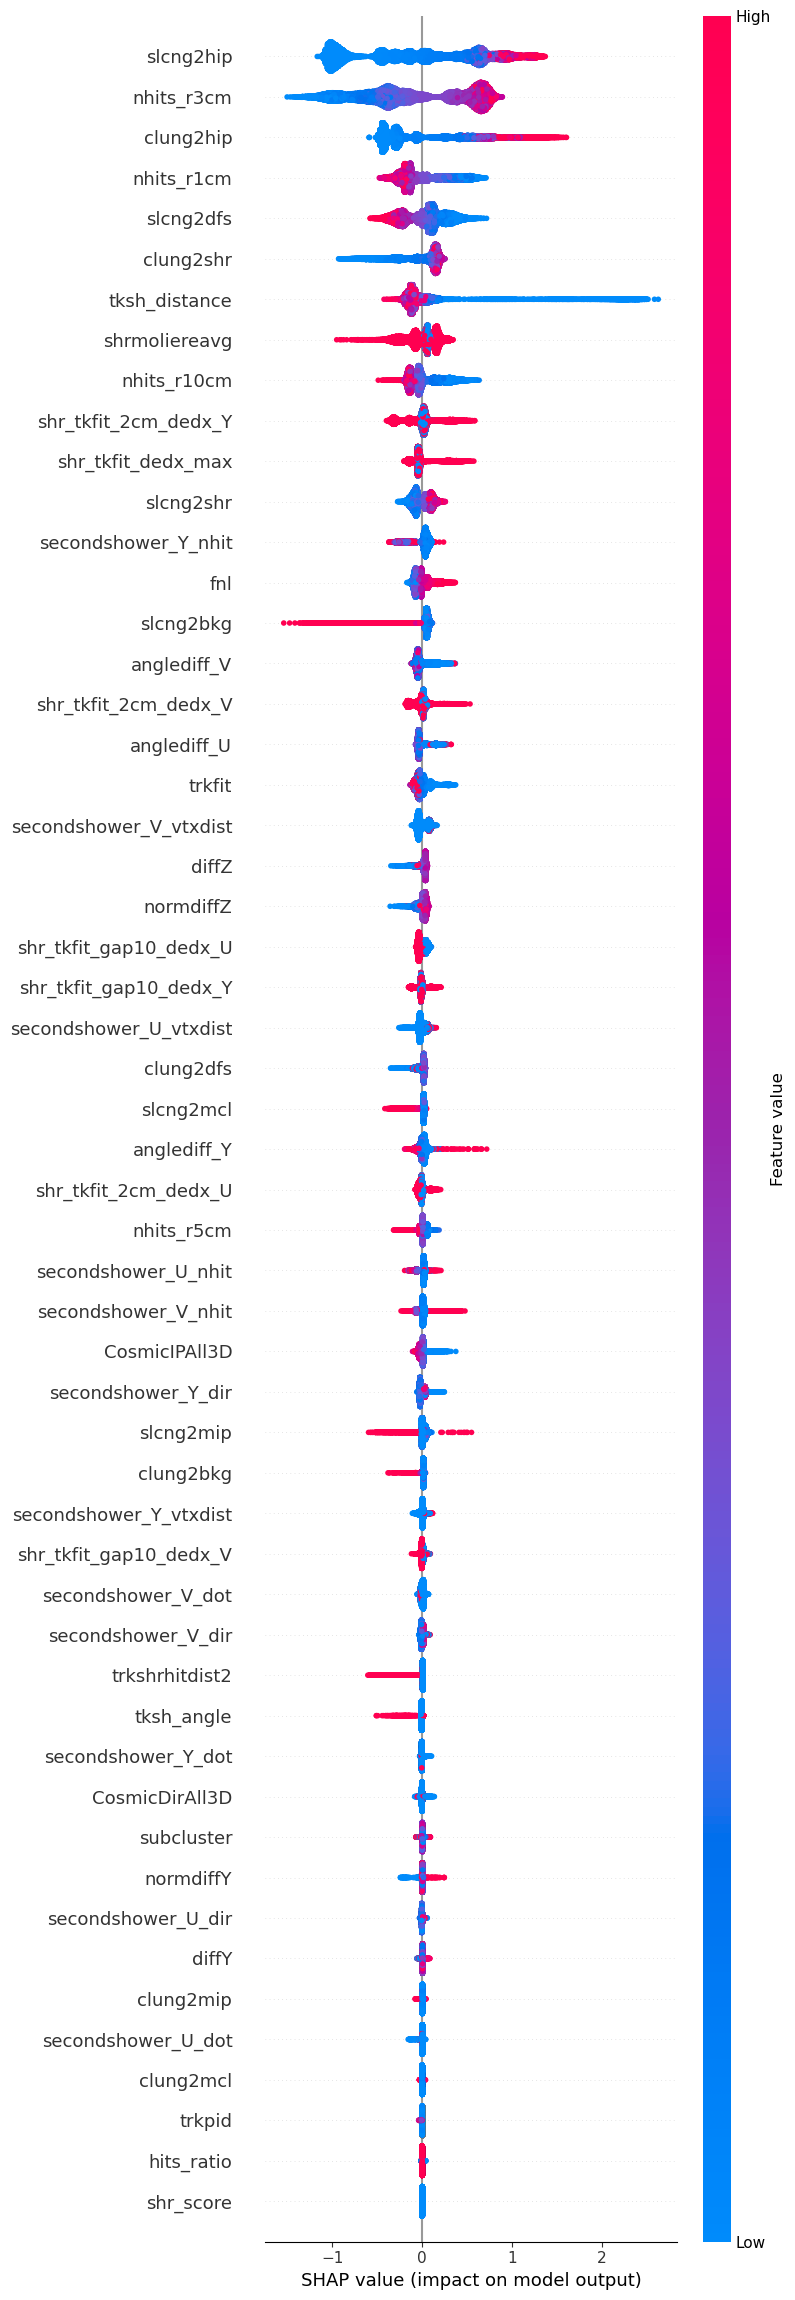

area under the precision-recall curve: 0.776847
precision score: 0.767149
recall score: 0.569241
Importance (total_gain):
clung2hip 84710.62294543999
slcng2hip 72802.84678429792
tksh_distance 29786.650232339995
nhits_r3cm 22948.352420480016
clung2shr 15479.698408666998
slcng2bkg 11465.261719730008
shr_tkfit_2cm_dedx_Y 10997.023147780015
slcng2dfs 9558.872176779987
nhits_r1cm 8704.257856205004
shr_tkfit_dedx_max 8609.973045960001
shrmoliereavg 7257.710087428
nhits_r10cm 5316.417978989001
slcng2mip 4606.788222200001
slcng2shr 4057.352196529999
anglediff_V 3677.139376810002
shr_tkfit_2cm_dedx_V 3663.5601428500004
secondshower_Y_nhit 3615.8948078799995
anglediff_Y 3238.749465776
trkfit 2953.8612014500018
fnl 2885.6121780000003
anglediff_U 2409.7731511800016
clung2bkg 2183.4342918
shr_tkfit_gap10_dedx_Y 2133.36476073
secondshower_V_vtxdist 1895.0044986080006
normdiffZ 1860.8690878330005
secondshower_V_nhit 1815.556883470001
slcng2mcl 1719.2070838400007
shr_tkfit_2cm_dedx_U 1706.291507938999

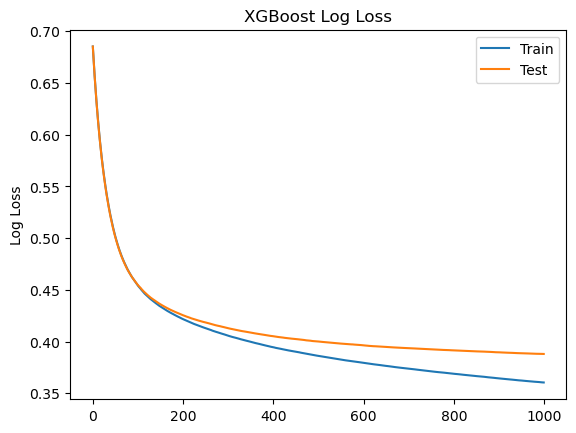

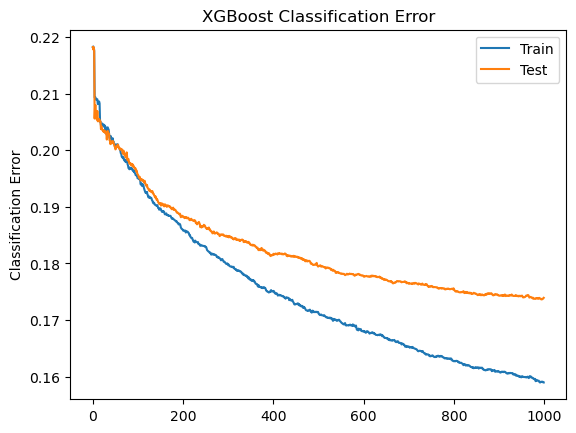

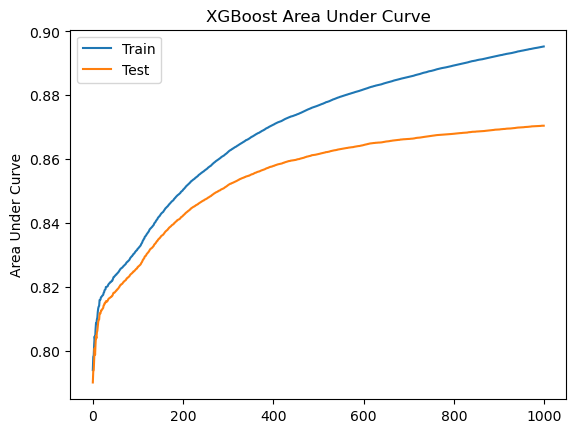

Training pi0...
&category!=10 and category!=11 and npi0>0
['shr_score', 'tksh_distance', 'tksh_angle', 'shr_tkfit_2cm_dedx_Y', 'shr_tkfit_2cm_dedx_U', 'shr_tkfit_2cm_dedx_V', 'shr_tkfit_gap10_dedx_Y', 'shr_tkfit_gap10_dedx_U', 'shr_tkfit_gap10_dedx_V', 'shr_tkfit_dedx_max', 'trkfit', 'trkpid', 'subcluster', 'shrmoliereavg', 'trkshrhitdist2', 'hits_ratio', 'CosmicIPAll3D', 'CosmicDirAll3D', 'secondshower_U_nhit', 'secondshower_U_vtxdist', 'secondshower_U_dot', 'secondshower_U_dir', 'anglediff_U', 'secondshower_V_nhit', 'secondshower_V_vtxdist', 'secondshower_V_dot', 'secondshower_V_dir', 'anglediff_V', 'secondshower_Y_nhit', 'secondshower_Y_vtxdist', 'secondshower_Y_dot', 'secondshower_Y_dir', 'anglediff_Y', 'slcng2mip', 'slcng2hip', 'slcng2shr', 'slcng2mcl', 'slcng2dfs', 'slcng2bkg', 'clung2mip', 'clung2hip', 'clung2shr', 'clung2mcl', 'clung2dfs', 'clung2bkg', 'nhits_r1cm', 'nhits_r3cm', 'nhits_r5cm', 'nhits_r10cm', 'diffY', 'normdiffY', 'diffZ', 'normdiffZ', 'fnl']
Validating...


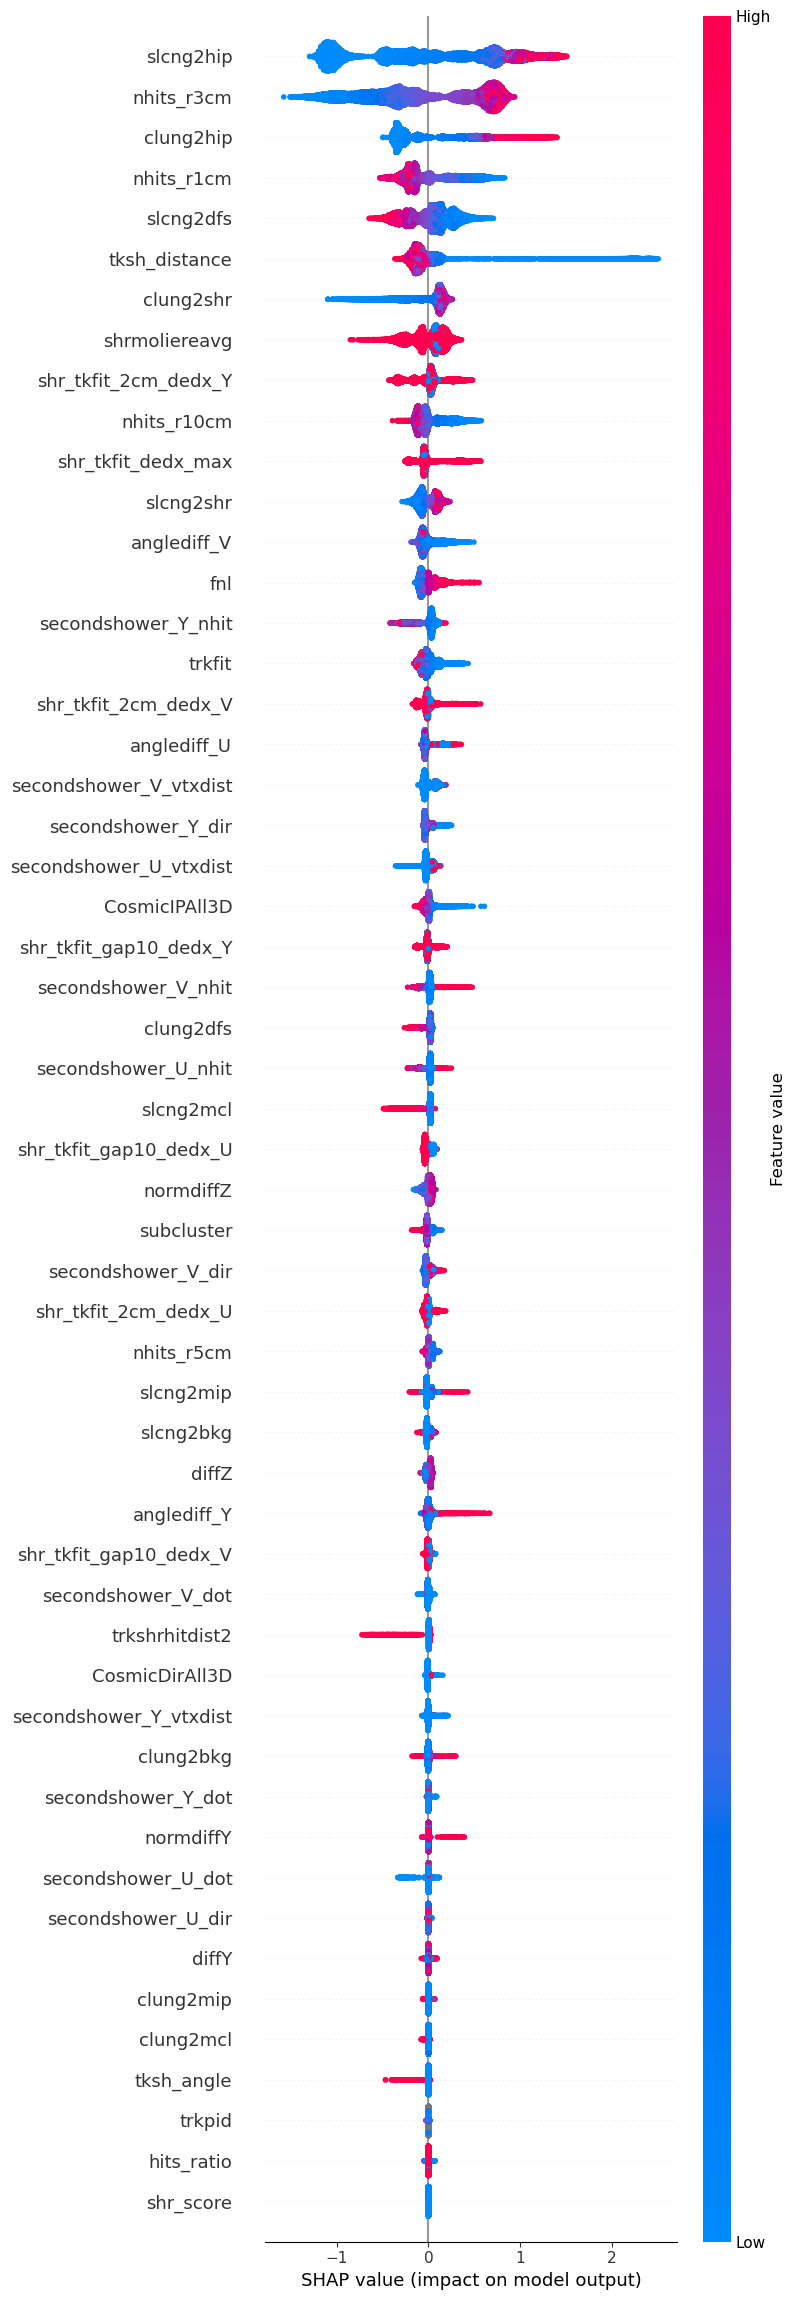

area under the precision-recall curve: 0.783935
precision score: 0.761580
recall score: 0.588428
Importance (total_gain):
slcng2hip 86011.39572445999
clung2hip 74124.55864350099
nhits_r3cm 25856.98123232002
tksh_distance 25101.835689390005
clung2shr 13621.502059326991
slcng2dfs 10628.90618559001
nhits_r1cm 9654.952495460004
shr_tkfit_2cm_dedx_Y 9440.495965290007
shr_tkfit_dedx_max 9316.281009663995
shrmoliereavg 7228.875468120002
anglediff_V 4520.642660240001
nhits_r10cm 4130.699172528998
slcng2shr 3840.549717572001
trkfit 3484.18469632
secondshower_Y_nhit 3281.7241479899994
shr_tkfit_2cm_dedx_V 3244.02902988
fnl 2621.431455649999
anglediff_U 2562.7568132800006
anglediff_Y 2488.8325181699993
shr_tkfit_gap10_dedx_Y 2201.72092461
secondshower_V_vtxdist 1969.8206291900008
CosmicIPAll3D 1959.1289018700006
secondshower_V_nhit 1802.57771117
secondshower_Y_dir 1476.7785351799998
slcng2mcl 1466.9446206900004
shr_tkfit_2cm_dedx_U 1458.4577255199995
clung2dfs 1446.6402369833006
secondshower_U_nh

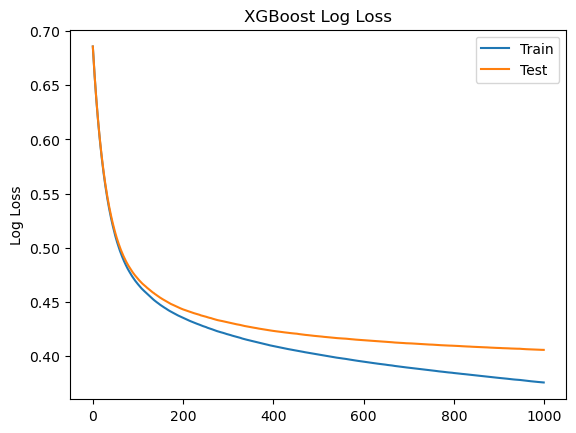

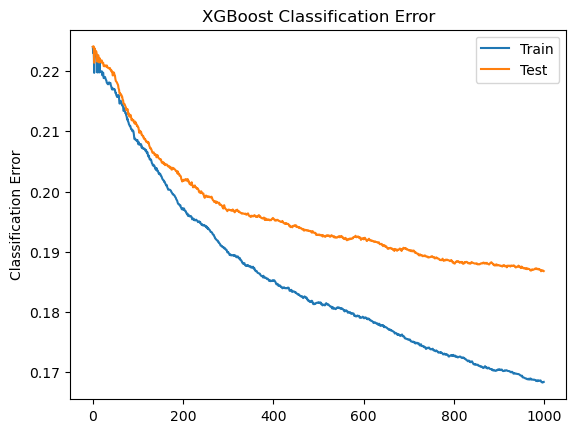

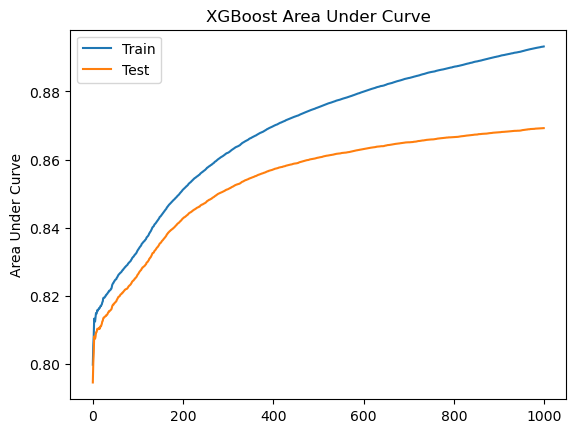

Training nonpi0...
&category!=10 and category!=11 and npi0==0
['shr_score', 'tksh_distance', 'tksh_angle', 'shr_tkfit_2cm_dedx_Y', 'shr_tkfit_2cm_dedx_U', 'shr_tkfit_2cm_dedx_V', 'shr_tkfit_gap10_dedx_Y', 'shr_tkfit_gap10_dedx_U', 'shr_tkfit_gap10_dedx_V', 'shr_tkfit_dedx_max', 'trkfit', 'trkpid', 'subcluster', 'shrmoliereavg', 'trkshrhitdist2', 'hits_ratio', 'CosmicIPAll3D', 'CosmicDirAll3D', 'secondshower_U_nhit', 'secondshower_U_vtxdist', 'secondshower_U_dot', 'secondshower_U_dir', 'anglediff_U', 'secondshower_V_nhit', 'secondshower_V_vtxdist', 'secondshower_V_dot', 'secondshower_V_dir', 'anglediff_V', 'secondshower_Y_nhit', 'secondshower_Y_vtxdist', 'secondshower_Y_dot', 'secondshower_Y_dir', 'anglediff_Y', 'slcng2mip', 'slcng2hip', 'slcng2shr', 'slcng2mcl', 'slcng2dfs', 'slcng2bkg', 'clung2mip', 'clung2hip', 'clung2shr', 'clung2mcl', 'clung2dfs', 'clung2bkg', 'nhits_r1cm', 'nhits_r3cm', 'nhits_r5cm', 'nhits_r10cm', 'diffY', 'normdiffY', 'diffZ', 'normdiffZ', 'fnl']
Validating...


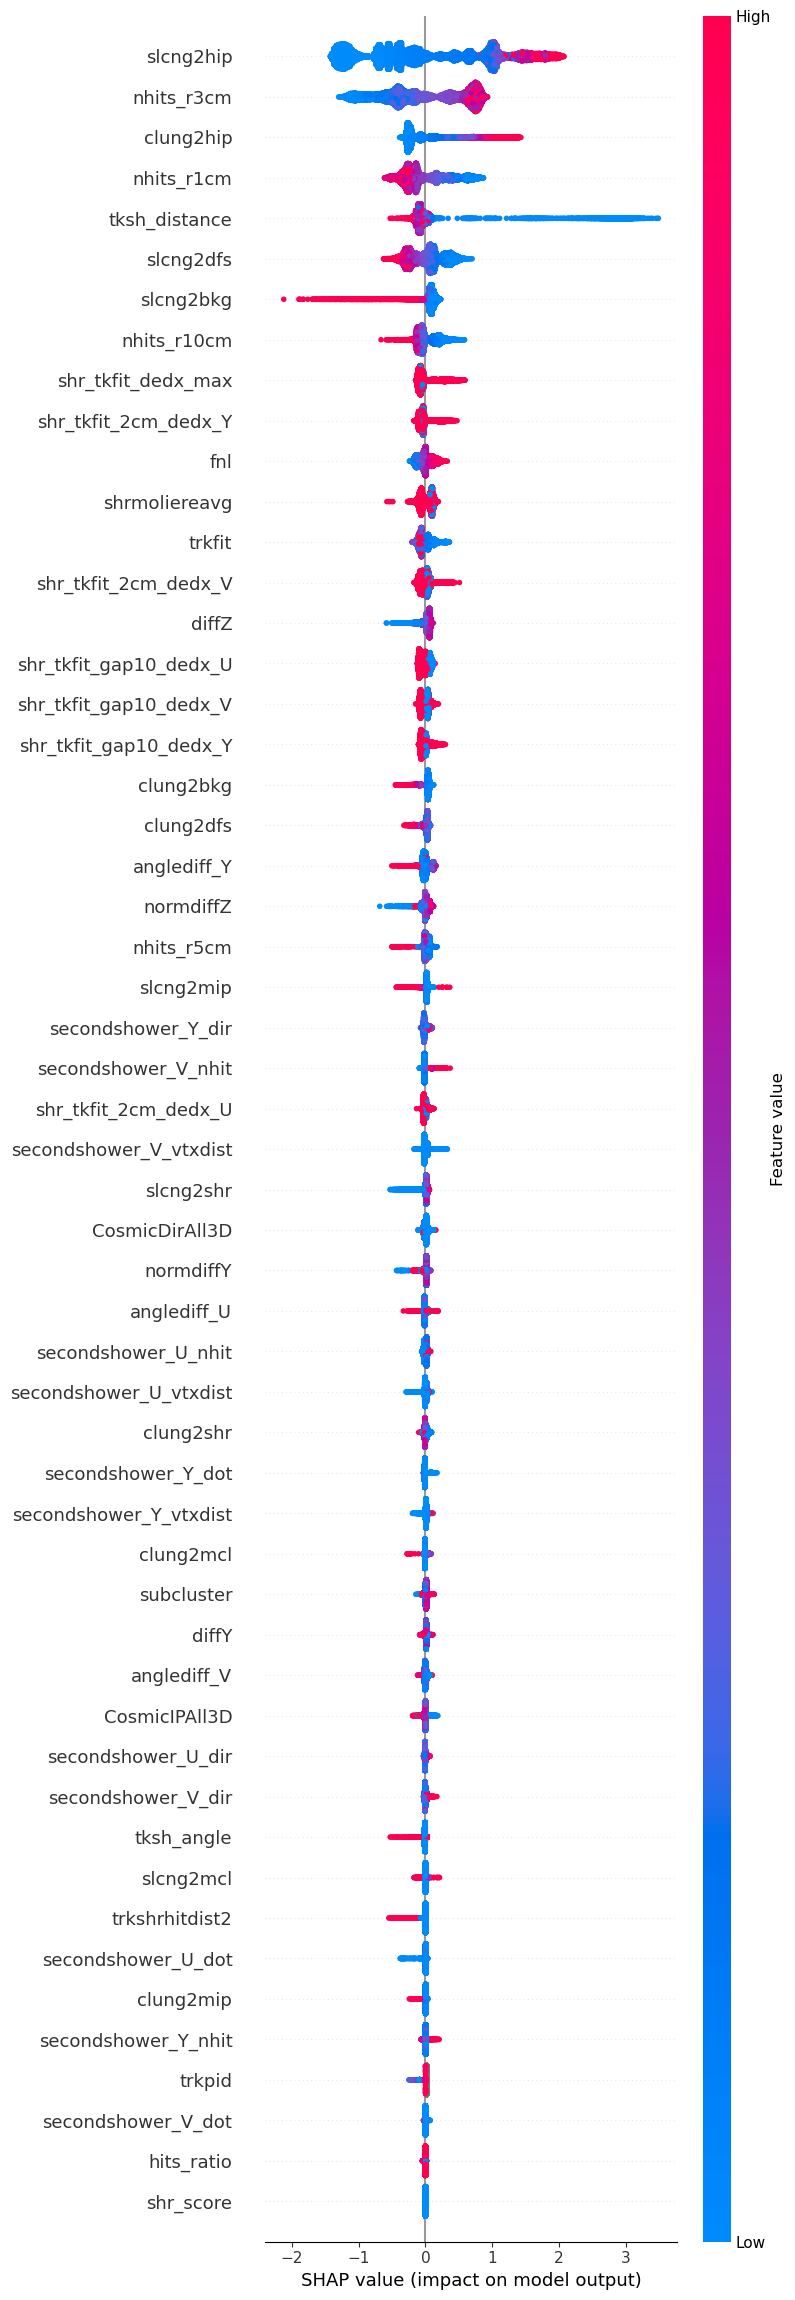

area under the precision-recall curve: 0.844880
precision score: 0.802281
recall score: 0.664380
Importance (total_gain):
slcng2hip 126441.60465031311
clung2hip 31119.296319337016
nhits_r3cm 21802.005089010047
slcng2bkg 21689.602650660043
tksh_distance 17772.92090227
nhits_r1cm 11469.912636932007
slcng2dfs 9175.472540596002
shr_tkfit_dedx_max 7864.181347388
shr_tkfit_2cm_dedx_Y 4411.422707912003
nhits_r10cm 4393.754021554999
clung2bkg 4192.620086529998
trkfit 3661.179857231301
anglediff_Y 3510.4665280699996
shr_tkfit_2cm_dedx_V 3134.708284531999
diffZ 3065.5468081299996
slcng2mip 2998.0012987299992
fnl 2871.4843535309997
clung2dfs 2808.7385516500008
shr_tkfit_gap10_dedx_Y 2692.600223460002
shrmoliereavg 2538.9717808880014
nhits_r5cm 2501.466976289
shr_tkfit_gap10_dedx_U 2370.03791512
shr_tkfit_gap10_dedx_V 2231.3563063308
normdiffZ 2094.0038247239995
slcng2shr 1533.4815190500008
shr_tkfit_2cm_dedx_U 1462.7723908839998
secondshower_Y_dir 1429.93944777
anglediff_V 1395.391895013
secondsh

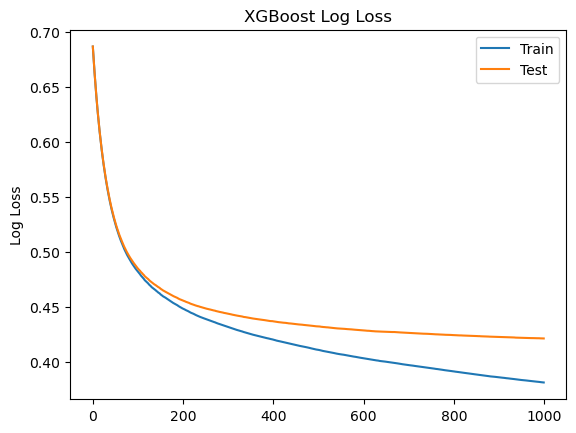

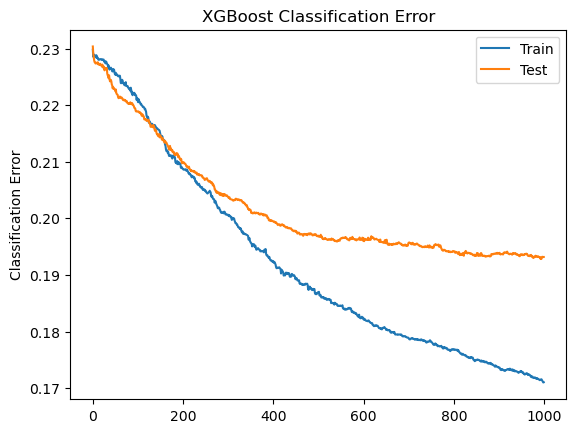

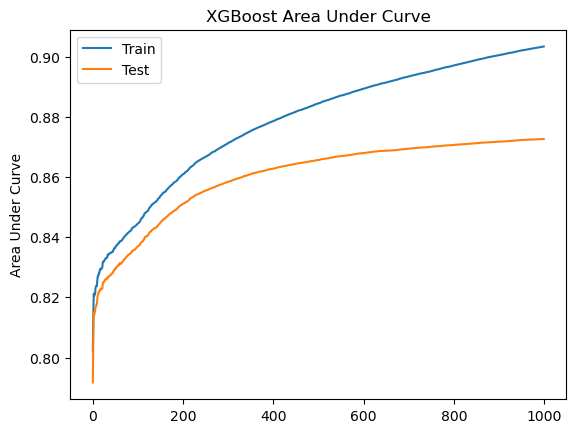

In [14]:
fig, ax = plt.subplots(1,1)

importlib.reload(nue_booster)
my_booster = nue_booster.NueBooster(samples, TRAINVAR, random_state=1990)

print (my_booster.variables)

# Nue Preselection
# PRESEL = 'slice_orig_pass_id == 1'
# PRESEL += ' and n_showers_contained == 1'
# PRESEL += ' and contained_fraction > 0.9'
# PRESEL += ' and shr_energy_tot_cali > 0.07'
# PRESEL += ' and ( (_opfilter_pe_beam > 0 and _opfilter_pe_veto < 20) or bnbdata == 1 or extdata == 1)'

# Extra Cosmic Rejection
# PRESEL += ' and CosmicIPAll3D > 10.'
# PRESEL += ' and trkfit < 0.65'

PRESEL = '( (_opfilter_pe_beam > 0 and _opfilter_pe_veto < 20) or bnbdata == 1 or extdata == 1)'
PRESEL += ' and n_tracks_contained == 0'

PRESEL += ' and crtveto != 1'

PRESEL += ' and CosmicIPAll3D > 10.'
PRESEL += ' and shrmoliereavg < 20'
PRESEL += ' and subcluster > 5'
PRESEL += ' and shr_trk_sce_start_y > -100 and shr_trk_sce_start_y < 100'
PRESEL += ' and shr_trk_len > 20'
PRESEL += ' and CylFrac2h_1cm < 0.7'
PRESEL += ' and shrMCSMom > 20'
PRESEL += ' and (n_tracks_tot == 0 or (n_tracks_tot>0 and tk1sh1_angle_alltk>-0.9))'

PRESEL += ' and diffZ > -70 and diffZ < 80'
PRESEL += ' and normdiffZ > -0.75 and normdiffZ < 0.75'
PRESEL += ' and fnl > -200 and fnl < 50'

# PRESEL += ' and slcng2hip < 40'
# PRESEL += ' and slcng2mip < 50'
# PRESEL += ' and slcng2mcl < 40'
# PRESEL += ' and clung2hip < 50'

# Old Loose Sel.
# PRESEL = '( (_opfilter_pe_beam > 0 and _opfilter_pe_veto < 20) or bnbdata == 1 or extdata == 1)'
# PRESEL += ' and n_tracks_contained == 0'
# PRESEL += ' and CosmicIPAll3D > 10.'
# PRESEL += ' and CosmicDirAll3D > -0.9 and CosmicDirAll3D < 0.9'
# PRESEL += ' and shrmoliereavg < 15'
# PRESEL += ' and subcluster > 4'
# PRESEL += ' and trkfit < 0.65'
# PRESEL += ' and secondshower_Y_nhit < 50'
# PRESEL += ' and shr_trk_sce_start_y > -100 and shr_trk_sce_start_y < 80'
# PRESEL += ' and shr_trk_sce_end_y > -100 and shr_trk_sce_end_y < 100 '
# PRESEL += ' and shr_trk_len < 300.'
# PRESEL += ' and (n_tracks_tot == 0 or (n_tracks_tot>0 and tk1sh1_angle_alltk>-0.9))'

my_booster.set_preselection(PRESEL)

gain_imp = {}

for label, bkg_query in zip(nue_booster.labels, nue_booster.bkg_queries):
    
    preds, gain_imp[label], evals_result, shap_values = my_booster.train_booster(ax, bkg_query)
    
    with open(ls.pickle_path+'booster_%s_45_11_0pnewloosesel_Npsignaltarget.pickle' % label, 'wb') as booster_file:
        pickle.dump(preds, booster_file)

    #print(evals_result)
    epochs = len(evals_result['train']['error'])
    x_axis = range(0, epochs)
    # plot log loss
    fig1, ax1 = plt.subplots()
    ax1.plot(x_axis, evals_result['train']['logloss'], label='Train')
    ax1.plot(x_axis, evals_result['eval']['logloss'], label='Test')
    ax1.legend()
    plt.ylabel('Log Loss')
    plt.title('XGBoost Log Loss')
    plt.show()
    # plot classification error
    fig2, ax2 = plt.subplots()
    ax2.plot(x_axis, evals_result['train']['error'], label='Train')
    ax2.plot(x_axis, evals_result['eval']['error'], label='Test')
    ax2.legend()
    plt.ylabel('Classification Error')
    plt.title('XGBoost Classification Error')
    plt.show()
    # plot auc
    fig3, ax3 = plt.subplots()
    ax3.plot(x_axis, evals_result['train']['auc'], label='Train')
    ax3.plot(x_axis, evals_result['eval']['auc'], label='Test')
    ax3.legend()
    plt.ylabel('Area Under Curve')
    plt.title('XGBoost Area Under Curve')
    plt.show()

    
ax.set_ylim([0, 1.05])
ax.set_xlim([0, 1.0])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC')
ax.legend()
fig.tight_layout()
#fig.savefig(ls.plots_path+"roc_single.pdf")

In [15]:
print('mc',train_nu.query(PRESEL)["train_weight"].sum())
print('nue',train_nue.query(PRESEL)["train_weight"].sum())
print('dirt',train_dirt.query(PRESEL)["train_weight"].sum())
print('ncpi0',train_ncpi0.query(PRESEL)["train_weight"].sum())
print('ext',train_ext.query(PRESEL)["train_weight"].sum())

mc 613.0
nue 30100.0
dirt 29.0
ncpi0 8124.0
ext 2600.0


In [16]:
print('mc',test_nu.query(PRESEL)["train_weight"].sum())
print('nue',test_nue.query(PRESEL)["train_weight"].sum())
print('dirt',test_dirt.query(PRESEL)["train_weight"].sum())
print('ncpi0',test_ncpi0.query(PRESEL)["train_weight"].sum())
print('ext',test_ext.query(PRESEL)["train_weight"].sum())

mc 606.0
nue 30254.0
dirt 22.0
ncpi0 8046.0
ext 3320.0


{'clung2hip': 74124.55864350099, 'slcng2hip': 86011.39572445999, 'nhits_r3cm': 25856.98123232002, 'tksh_distance': 25101.835689390005, 'shrmoliereavg': 7228.875468120002, 'slcng2dfs': 10628.90618559001, 'shr_tkfit_dedx_max': 9316.281009663995, 'clung2shr': 13621.502059326991, 'trkfit': 3484.18469632, 'secondshower_U_nhit': 1409.4369599910003, 'secondshower_Y_nhit': 3281.7241479899994, 'shr_tkfit_2cm_dedx_Y': 9440.495965290007, 'secondshower_Y_dir': 1476.7785351799998, 'clung2mip': 355.54456648200005, 'slcng2shr': 3840.549717572001, 'secondshower_V_nhit': 1802.57771117, 'anglediff_V': 4520.642660240001, 'tksh_angle': 178.51101064, 'secondshower_Y_vtxdist': 1068.767941989, 'slcng2mip': 1225.9650730899996, 'trkpid': 53.5441141, 'shr_tkfit_2cm_dedx_U': 1458.4577255199995, 'shr_tkfit_gap10_dedx_U': 1089.7256398400004, 'nhits_r1cm': 9654.952495460004, 'slcng2mcl': 1466.9446206900004, 'secondshower_V_vtxdist': 1969.8206291900008, 'anglediff_U': 2562.7568132800006, 'CosmicIPAll3D': 1959.128901

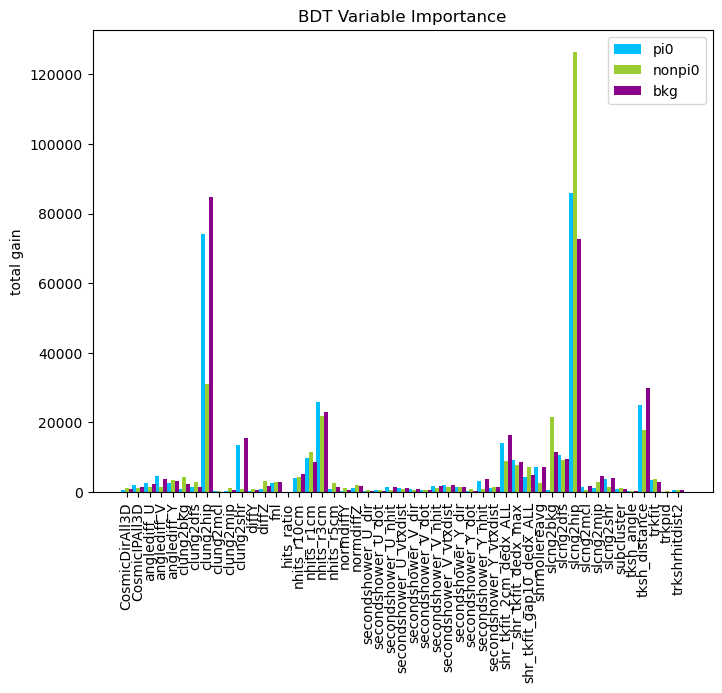

In [17]:
print(gain_imp['pi0'])
print(gain_imp['nonpi0'])
print(gain_imp['bkg'])

if 'shr_tkfit_gap10_dedx_V' in gain_imp['pi0']:
    gain_imp['pi0']['shr_tkfit_gap10_dedx_ALL'] = gain_imp['pi0']['shr_tkfit_gap10_dedx_V']+gain_imp['pi0']['shr_tkfit_gap10_dedx_U']+gain_imp['pi0']['shr_tkfit_gap10_dedx_Y']
    gain_imp['nonpi0']['shr_tkfit_gap10_dedx_ALL'] = gain_imp['nonpi0']['shr_tkfit_gap10_dedx_V']+gain_imp['nonpi0']['shr_tkfit_gap10_dedx_U']+gain_imp['nonpi0']['shr_tkfit_gap10_dedx_Y']
    gain_imp['bkg']['shr_tkfit_gap10_dedx_ALL'] = gain_imp['bkg']['shr_tkfit_gap10_dedx_V']+gain_imp['bkg']['shr_tkfit_gap10_dedx_U']+gain_imp['bkg']['shr_tkfit_gap10_dedx_Y']
    del gain_imp['pi0']['shr_tkfit_gap10_dedx_V']
    del gain_imp['pi0']['shr_tkfit_gap10_dedx_U']
    del gain_imp['pi0']['shr_tkfit_gap10_dedx_Y']
    del gain_imp['nonpi0']['shr_tkfit_gap10_dedx_V']
    del gain_imp['nonpi0']['shr_tkfit_gap10_dedx_U']
    del gain_imp['nonpi0']['shr_tkfit_gap10_dedx_Y']
    del gain_imp['bkg']['shr_tkfit_gap10_dedx_V']
    del gain_imp['bkg']['shr_tkfit_gap10_dedx_U']
    del gain_imp['bkg']['shr_tkfit_gap10_dedx_Y']
if 'shr_tkfit_2cm_dedx_V' in gain_imp['pi0']:
    gain_imp['pi0']['shr_tkfit_2cm_dedx_ALL'] = gain_imp['pi0']['shr_tkfit_2cm_dedx_V']+gain_imp['pi0']['shr_tkfit_2cm_dedx_U']+gain_imp['pi0']['shr_tkfit_2cm_dedx_Y']
    gain_imp['nonpi0']['shr_tkfit_2cm_dedx_ALL'] = gain_imp['nonpi0']['shr_tkfit_2cm_dedx_V']+gain_imp['nonpi0']['shr_tkfit_2cm_dedx_U']+gain_imp['nonpi0']['shr_tkfit_2cm_dedx_Y']
    gain_imp['bkg']['shr_tkfit_2cm_dedx_ALL'] = gain_imp['bkg']['shr_tkfit_2cm_dedx_V']+gain_imp['bkg']['shr_tkfit_2cm_dedx_U']+gain_imp['bkg']['shr_tkfit_2cm_dedx_Y']
    del gain_imp['pi0']['shr_tkfit_2cm_dedx_V']
    del gain_imp['pi0']['shr_tkfit_2cm_dedx_U']
    del gain_imp['pi0']['shr_tkfit_2cm_dedx_Y']
    del gain_imp['nonpi0']['shr_tkfit_2cm_dedx_V']
    del gain_imp['nonpi0']['shr_tkfit_2cm_dedx_U']
    del gain_imp['nonpi0']['shr_tkfit_2cm_dedx_Y']
    del gain_imp['bkg']['shr_tkfit_2cm_dedx_V']
    del gain_imp['bkg']['shr_tkfit_2cm_dedx_U']
    del gain_imp['bkg']['shr_tkfit_2cm_dedx_Y']

print(gain_imp['bkg'])
# print(gain_imp['bkg']['shr_tkfit_2cm_dedx_ALL'])

labels = []
pi0_imp = []
nonpi0_imp = []
bkg_imp = []

for i in sorted (gain_imp['pi0'].keys()) :  
    labels.append(i)
    pi0_imp.append(gain_imp['pi0'][i])
    nonpi0_imp.append(gain_imp['nonpi0'][i])
    bkg_imp.append(gain_imp['bkg'][i])
    
x = np.arange(len(labels))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots(figsize=(8,6))
rects1 = ax.bar(x - width, pi0_imp, width, label='pi0', color='deepskyblue')
rects2 = ax.bar(x, nonpi0_imp, width, label='nonpi0', color='yellowgreen')
rects3 = ax.bar(x + width, bkg_imp, width, label='bkg', color='darkmagenta')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('total gain')
ax.set_title('BDT Variable Importance')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation = 90)
ax.legend()

plt.show()
fig.tight_layout()
#fig.savefig(ls.plots_path+"0109/bdt_var_gain.pdf")
#fig.savefig(ls.plots_path+"bdt_var_gain.pdf")

{'slcng2hip': 49, 'clung2hip': 48, 'nhits_r3cm': 47, 'tksh_distance': 46, 'shr_tkfit_2cm_dedx_ALL': 45, 'clung2shr': 44, 'slcng2dfs': 43, 'nhits_r1cm': 42, 'shr_tkfit_dedx_max': 41, 'shrmoliereavg': 40, 'anglediff_V': 39, 'shr_tkfit_gap10_dedx_ALL': 38, 'nhits_r10cm': 37, 'slcng2shr': 36, 'trkfit': 35, 'secondshower_Y_nhit': 34, 'fnl': 33, 'anglediff_U': 32, 'anglediff_Y': 31, 'secondshower_V_vtxdist': 30, 'CosmicIPAll3D': 29, 'secondshower_V_nhit': 28, 'secondshower_Y_dir': 27, 'slcng2mcl': 26, 'clung2dfs': 25, 'secondshower_U_nhit': 24, 'slcng2mip': 23, 'secondshower_U_vtxdist': 22, 'secondshower_Y_vtxdist': 21, 'normdiffZ': 20, 'nhits_r5cm': 19, 'secondshower_V_dir': 18, 'diffZ': 17, 'subcluster': 16, 'clung2bkg': 15, 'trkshrhitdist2': 14, 'slcng2bkg': 13, 'secondshower_V_dot': 12, 'CosmicDirAll3D': 11, 'secondshower_U_dot': 10, 'diffY': 9, 'normdiffY': 8, 'clung2mip': 7, 'secondshower_Y_dot': 6, 'secondshower_U_dir': 5, 'tksh_angle': 4, 'clung2mcl': 3, 'hits_ratio': 2, 'trkpid': 1}

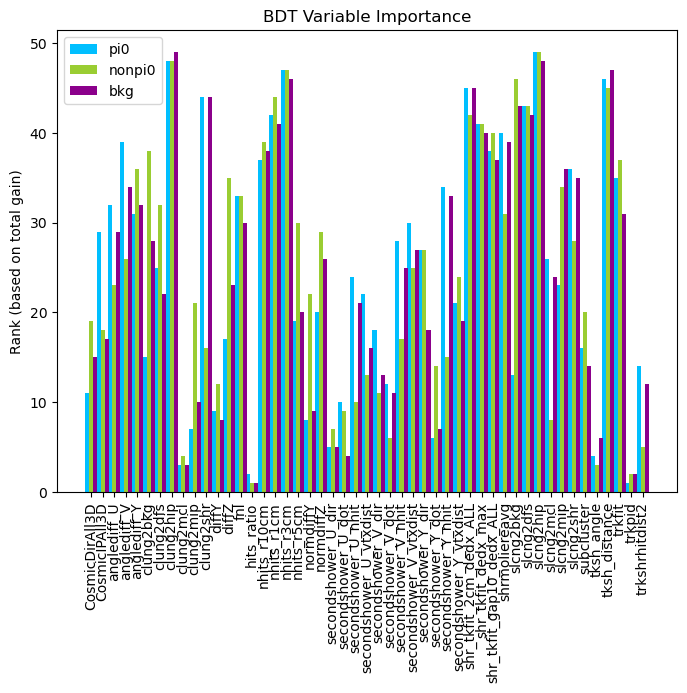

In [18]:
d_pi0_rnk = {}
rnk = len(labels)
for w in sorted(gain_imp['pi0'], key=gain_imp['pi0'].get, reverse=True):
    d_pi0_rnk[w] = rnk
    rnk = rnk-1
print(d_pi0_rnk)

d_nonpi0_rnk = {}
rnk = len(labels)
for w in sorted(gain_imp['nonpi0'], key=gain_imp['nonpi0'].get, reverse=True):
    d_nonpi0_rnk[w] = rnk
    rnk = rnk-1
print(d_nonpi0_rnk)

d_bkg_rnk = {}
rnk = len(labels)
for w in sorted(gain_imp['bkg'], key=gain_imp['bkg'].get, reverse=True):
    d_bkg_rnk[w] = rnk
    rnk = rnk-1
print(d_bkg_rnk)

pi0_rnk = []
nonpi0_rnk = []
bkg_rnk = []

for i in labels:  
    pi0_rnk.append(d_pi0_rnk[i])
    nonpi0_rnk.append(d_nonpi0_rnk[i])
    bkg_rnk.append(d_bkg_rnk[i])
    
x = np.arange(len(labels))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots(figsize=(8,6))
rects1 = ax.bar(x - width, pi0_rnk, width, label='pi0', color='deepskyblue')
rects2 = ax.bar(x, nonpi0_rnk, width, label='nonpi0', color='yellowgreen')
rects3 = ax.bar(x + width, bkg_rnk, width, label='bkg', color='darkmagenta')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Rank (based on total gain)')
ax.set_title('BDT Variable Importance')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation = 90)
ax.legend()

plt.show()
fig.tight_layout()
#fig.savefig(ls.plots_path+"0109/bdt_var_rank.pdf")
#fig.savefig(ls.plots_path+"bdt_var_rank.pdf")